# 1. Préparation de l'environnement
Nous importons les librairies nécessaires : `pandas` pour la manipulation de données, `spacy` pour le traitement linguistique, et `sklearn` pour le Machine Learning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuration visuelle
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")

print("Librairies chargées avec succès !")

Librairies chargées avec succès !


# 2. Chargement du Dataset
Le fichier contient le catalogue produits. Nous allons charger les données brutes situées dans le dossier `data/raw`.

In [5]:
# On remonte d'un dossier (..) pour accéder à data/raw
try:
    df = pd.read_csv('../data/raw/sample-data.csv')
    print(f"Dataset chargé : {df.shape[0]} produits, {df.shape[1]} colonnes.")
    display(df.head(3))
except FileNotFoundError:
    print("❌ ERREUR : Fichier introuvable. Vérifie qu'il est bien dans 'data/raw/sample-data.csv'")

Dataset chargé : 500 produits, 2 colonnes.


,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...


# 3. Preprocessing (Nettoyage du texte)
Pour que l'algorithme comprenne nos produits, nous devons nettoyer la colonne `description`.
**Étapes :**
1. Tokenization (découpage en mots).
2. Suppression des "Stop Words" (le, la, of, the...).
3. Lemmatization (garder la racine du mot : "running" -> "run").

In [6]:
# Chargement du dictionnaire anglais
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("❌ Modèle Spacy manquant. Lance 'python -m spacy download en_core_web_sm' dans ton terminal.")

def clean_text(text):
    """
    Nettoie le texte : minuscule, lemmatization, suppression stop words & ponctuation.
    """
    if pd.isna(text): 
        return ""
    
    doc = nlp(text)
    
    # On garde les tokens qui sont alphabétiques, pas des stop words, et > 2 lettres
    tokens = [token.lemma_.lower() for token in doc 
              if not token.is_stop 
              and not token.is_punct 
              and token.is_alpha
              and len(token) > 2]
    
    return " ".join(tokens)

# Test sur une phrase exemple
phrase_test = "The North Face creates amazing jackets for running in the mountains!"
print(f"Avant : {phrase_test}")
print(f"Après : {clean_text(phrase_test)}")

Avant : The North Face creates amazing jackets for running in the mountains!
Après : north face create amazing jacket run mountain


# Application du nettoyage
Nous appliquons cette fonction à l'ensemble du catalogue. Cela crée une nouvelle colonne `clean_description`.

In [7]:
# Attention : cela peut prendre 1 à 2 minutes selon la puissance de ton PC
print("⏳ Nettoyage en cours...")
df['clean_description'] = df['description'].apply(clean_text)

print("✅ Terminé ! Aperçu :")
display(df[['description', 'clean_description']].head())

⏳ Nettoyage en cours...
✅ Terminé ! Aperçu :


,description,clean_description
0,Active classic boxers - There's a reason why o...,active classic boxer reason boxer cult favorit...
1,Active sport boxer briefs - Skinning up Glory ...,active sport boxer brief skin glory require mo...
2,Active sport briefs - These superbreathable no...,active sport brief superbreathable fly brief m...
3,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pant skin climb ice switch rock t...
4,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt high ridge steep ice alpine ja...


# 4. Feature Extraction : TF-IDF
Nous allons transformer nos descriptions textuelles en vecteurs numériques.
Nous utilisons **TF-IDF** (Term Frequency - Inverse Document Frequency).
* Cela donne un poids élevé aux mots rares et importants (ex: "gore-tex").
* Cela donne un poids faible aux mots trop fréquents (ex: "wear", "cloth").

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# On instancie le vectoriseur
# max_features=1000 : On garde uniquement les 1000 mots les plus pertinents pour limiter le bruit
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# On l'entraîne et on transforme nos descriptions
print("🔄 Vectorisation en cours...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_description'])

print(f"✅ Matrice créée : {tfidf_matrix.shape}")
# (Nombre de produits, Nombre de mots uniques retenus)

🔄 Vectorisation en cours...
✅ Matrice créée : (500, 1000)


# 5. Clustering : DBSCAN
Nous allons regrouper les produits similaires sans leur donner de catégories à l'avance (Apprentissage Non Supervisé).
Nous utilisons l'algorithme **DBSCAN** car il gère bien le bruit (outliers).

**Paramètres clés :**
* `metric='cosine'` : Indispensable pour du texte (mesure l'angle entre les vecteurs plutôt que la distance brute).
* `eps` : La distance maximale entre deux produits pour qu'ils soient considérés comme "voisins".
* `min_samples` : Le nombre minimum de produits pour former un groupe.

In [9]:
from sklearn.cluster import DBSCAN

# Configuration de DBSCAN
# Note : Ces paramètres (eps=0.2, min_samples=3) sont des points de départ.
# En situation réelle, il faudrait tester plusieurs valeurs.
dbscan = DBSCAN(eps=0.2, min_samples=3, metric='cosine')

# Entraînement
print("🤖 Entraînement du modèle DBSCAN...")
clusters = dbscan.fit_predict(tfidf_matrix)

# Ajout des clusters au DataFrame
df['cluster'] = clusters

# Analyse des résultats
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"✅ Résultat : {n_clusters} clusters trouvés.")
print(f"⚠️ Nombre de produits 'bruit' (non classés, cluster -1) : {n_noise}")

# Affichons quelques exemples par cluster
display(df[['description', 'cluster']].sort_values(by='cluster').head(10))

🤖 Entraînement du modèle DBSCAN...
✅ Résultat : 19 clusters trouvés.
⚠️ Nombre de produits 'bruit' (non classés, cluster -1) : 401


,description,cluster
491,Freedom to roam t-shirt - Global warming and h...,-1
14,Borderless shorts-11 in. - Go forward where ot...,-1
13,Better sweater jkt - June nights camped out in...,-1
12,Beach bucket - Whenever you're at the junction...,-1
497,All-time shell - No need to use that morning T...,-1
498,All-wear cargo shorts - All-Wear Cargo Shorts ...,-1
25,City by the sea t-shirt - Illustrating the ren...,-1
24,Cap 4 bottoms - For sufferfests like the Grand...,-1
23,Cap 3 zip neck - Capilene 3 provides excellent...,-1
22,Cap 2 zip neck - Designed for wet-then-chill p...,-1


✅ Clusters : 17
📉 Bruit restant : 20 (4.0%)

Distribution des clusters :
cluster
 1     295
 0      61
 2      28
 8      24
-1      20
 3      11
 5       8
 11      7
 7       6
 4       6
 15      6
 16      5
 10      5
 6       4
 13      4
 9       4
 12      3
 14      3
Name: count, dtype: int64

Visualisation des thèmes dominants :


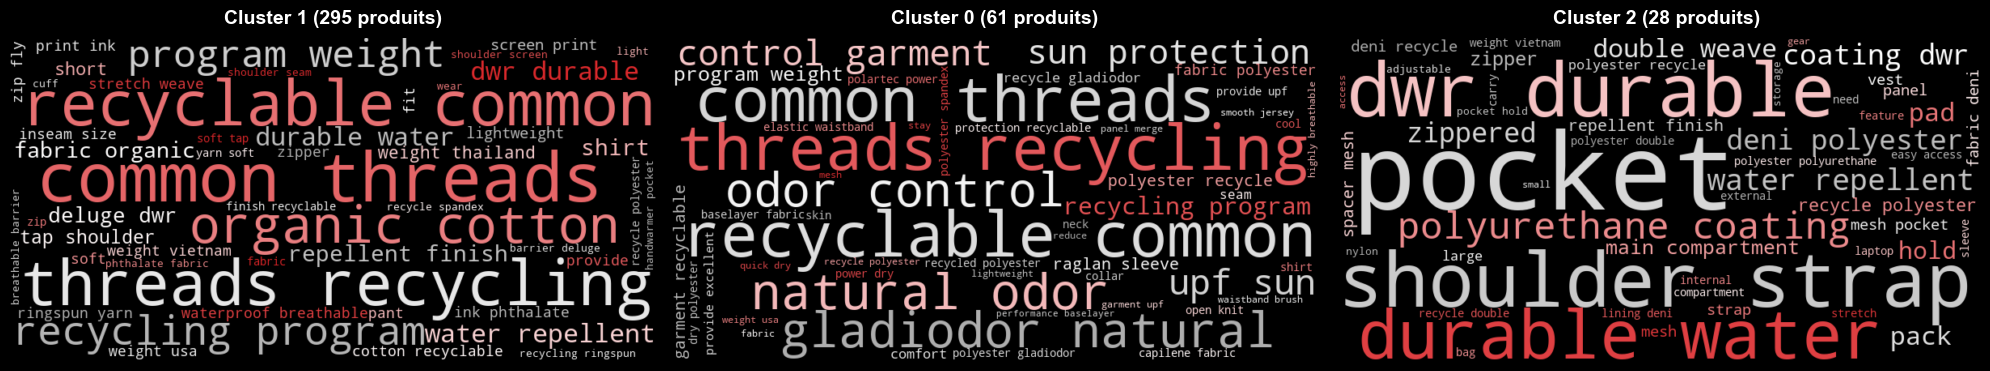

In [10]:
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap

# Palette TNF : rouge #DA2427 pour les mots dominants, dégradé vers blanc/gris clair
tnf_cmap = LinearSegmentedColormap.from_list(
    "tnf", ["#AAAAAA", "#FFFFFF", "#DA2427"], N=256
)

# 1. Nouvel essai avec eps optimisé pour atteindre 10-20 clusters (cible de l'énoncé)
# eps=0.2 → 19 clusters mais 80% outliers (trop restrictif)
# eps=0.63 → 17 clusters et seulement 4% outliers (bon compromis)
dbscan = DBSCAN(eps=0.63, min_samples=3, metric='cosine')
df['cluster'] = dbscan.fit_predict(tfidf_matrix)

# Stats rapides
n_clusters_final = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_noise_final = (df['cluster'] == -1).sum()
print(f"✅ Clusters : {n_clusters_final}")
print(f"📉 Bruit restant : {n_noise_final} ({n_noise_final/len(df)*100:.1f}%)")
print(f"\nDistribution des clusters :")
print(df['cluster'].value_counts())

# 2. Visualisation des WordClouds pour les 3 plus gros clusters (hors bruit)
def plot_wordclouds(df, n_clusters=3):
    unique_clusters = df[df['cluster'] != -1]['cluster'].value_counts().index[:n_clusters]
    
    fig, axes = plt.subplots(1, n_clusters, figsize=(20, 5), facecolor='black')
    for i, cluster_id in enumerate(unique_clusters):
        text_cluster = " ".join(df[df['cluster'] == cluster_id]['clean_description'])
        
        wc = WordCloud(
            background_color='black',
            max_words=50,
            colormap=tnf_cmap,
            width=800, height=400
        ).generate(text_cluster)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(
            f"Cluster {cluster_id} ({(df['cluster']==cluster_id).sum()} produits)",
            color='white', fontsize=14, fontweight='bold', pad=10
        )
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

print("\nVisualisation des thèmes dominants :")
plot_wordclouds(df)

In [11]:
def find_similar_items(item_id, df):
    """
    Retourne 5 produits similaires basés sur le cluster.
    """
    # 1. Trouver le cluster du produit demandé
    try:
        target_cluster = df.loc[item_id, 'cluster']
    except KeyError:
        return "ID produit inconnu."
        
    # Si c'est du bruit (-1), on ne peut rien recommander de précis
    if target_cluster == -1:
        return "Ce produit est unique (Outlier), pas de recommandation évidente."
    
    # 2. Trouver d'autres produits du même cluster (en excluant le produit lui-même)
    similar_items = df[
        (df['cluster'] == target_cluster) & 
        (df.index != item_id)
    ]
    
    # 3. En prendre 5 au hasard (ou tous s'il y en a moins de 5)
    if len(similar_items) > 0:
        recommendations = similar_items.sample(n=min(5, len(similar_items)))
        return recommendations[['description', 'cluster']]
    else:
        return "Aucun autre produit similaire trouvé dans ce cluster."

# --- TEST AUTOMATIQUE (pour vérifier que la fonction marche) ---
sample_id = df[df['cluster'] != -1].sample(1).index[0]
print(f"🔎 Produit consulté (ID {sample_id}) :")
print(df.loc[sample_id, 'description'][:200])
print("-" * 50)
print("💡 Vous aimerez aussi :")
display(find_similar_items(sample_id, df))

🔎 Produit consulté (ID 296) :
Versatiliti cardi - A summer-weight cardigan for the woman who studies abroad one month; crags, surfs and lives out of her car the next. This versatile, low-maintenance sweater is made from a soft 62%
--------------------------------------------------
💡 Vous aimerez aussi :


,description,cluster
128,"Sst jkt - Bristol Bay, Tierra del Fuego, the R...",1
123,Squid t-shirt - Artist Tim Tompkinson's origin...,1
416,Micro d-luxe cardigan - A Micro D-Luxe Cardiga...,1
459,Araveto hooded jkt - For the deep chill of a f...,1
306,Island hemp dress - The soft hand of the Islan...,1


In [12]:
# --- MODE INTERACTIF (input) ---
# L'utilisateur saisit l'ID d'un produit pour obtenir des recommandations
user_input = input("Entrez l'ID d'un produit (0 à 499) : ")

try:
    user_id = int(user_input)
    print(f"\n🔎 Produit consulté (ID {user_id}) :")
    print(df.loc[user_id, 'description'][:200])
    print("-" * 50)
    print("💡 Vous aimerez aussi :")
    result = find_similar_items(user_id, df)
    if isinstance(result, str):
        print(result)
    else:
        display(result)
except (ValueError, KeyError):
    print("❌ ID invalide. Veuillez entrer un nombre entre 0 et 499.")


🔎 Produit consulté (ID 400) :
Reversible phone home - Travel broadly and surf the world, but don't forget to call your mom. Now reversible for road-trip rejuvenation, the inimitable hooded Phone Home Jacket helps us keep in touch.
--------------------------------------------------
💡 Vous aimerez aussi :


,description,cluster
38,Elias sweatshirt - The dirtbagger's complete w...,4
403,Hooded monk sweatshirt - The sacred garment of...,4
278,Cotton fleece hoody - When Central Coast night...,4
197,Mandeville hoody - A going-places hoody. The M...,4
37,Elias fz sweatshirt - Clean as a Wingate split...,4


# 6. Topic Modeling : LSA (Latent Semantic Analysis)
Dernière étape : nous allons extraire les thèmes latents du corpus pour comprendre la structure globale du catalogue.
Nous utilisons **TruncatedSVD** pour réduire la dimensionnalité de la matrice TF-IDF.

In [13]:
from sklearn.decomposition import TruncatedSVD

# 1. Configuration du modèle
# On cherche 10 "sujets" principaux dans le catalogue
n_topics = 10
lsa_model = TruncatedSVD(n_components=n_topics, random_state=42)

# 2. Entraînement et sauvegarde dans topic_encoded_df (nom imposé par l'énoncé)
topic_encoded_df = lsa_model.fit_transform(tfidf_matrix)
print(f"✅ Matrice topic : {topic_encoded_df.shape}")
print(f"📊 Variance expliquée totale : {lsa_model.explained_variance_ratio_.sum()*100:.1f}%")

# 3. Affichage des mots clés de chaque thème
def display_topics(model, feature_names, no_top_words):
    print("\n🔎 Les thèmes découverts dans le catalogue :\n")
    for topic_idx, topic in enumerate(model.components_):
        term_indices = topic.argsort()[:-no_top_words - 1:-1]
        keywords = [feature_names[i] for i in term_indices]
        print(f"Topic {topic_idx + 1}: {', '.join(keywords)}")

feature_names = tfidf_vectorizer.get_feature_names_out()
display_topics(lsa_model, feature_names, 10)

# 4. Extraction du topic dominant par document
df['main_topic'] = topic_encoded_df.argmax(axis=1) + 1  # +1 pour indexer à partir de 1

print(f"\n📌 Distribution des topics dominants :")
print(df['main_topic'].value_counts().sort_index())

✅ Matrice topic : (500, 10)
📊 Variance expliquée totale : 25.1%

🔎 Les thèmes découverts dans le catalogue :

Topic 1: organic, cotton, recyclable, common, threads, recycling, shirt, pocket, fabric, shoulder
Topic 2: shirt, tap, ringspun, phthalate, print, ink, organic, cotton, screen, yarn
Topic 3: merino, odor, control, gladiodor, natural, wool, capilene, knit, skin, wash
Topic 4: organic, button, cotton, short, canvas, jean, inseam, welt, zip, size
Topic 5: merino, wool, wash, lie, naturally, chlorine, cold, core, resist, luxurious
Topic 6: sun, upf, nylon, protection, print, spandex, inseam, belt, usa, size
Topic 7: strap, pocket, mesh, polyurethane, deni, compartment, coating, shoulder, access, polyester
Topic 8: spandex, strap, blend, coverage, tencel, bra, hip, dress, lined, organic
Topic 9: photo, poster, photograph, outdoor, brighten, passion, retail, specialty, clothier, site
Topic 10: sun, upf, protection, collar, shirt, organic, merino, chest, rashguard, recycle

📌 Distribu

# WordClouds des Topics LSA
Chaque topic est défini par ses mots à plus fort poids dans la composante SVD.
Contrairement au clustering, un produit peut contribuer à **plusieurs topics** simultanément.

🎨 WordClouds des 6 premiers topics LSA :


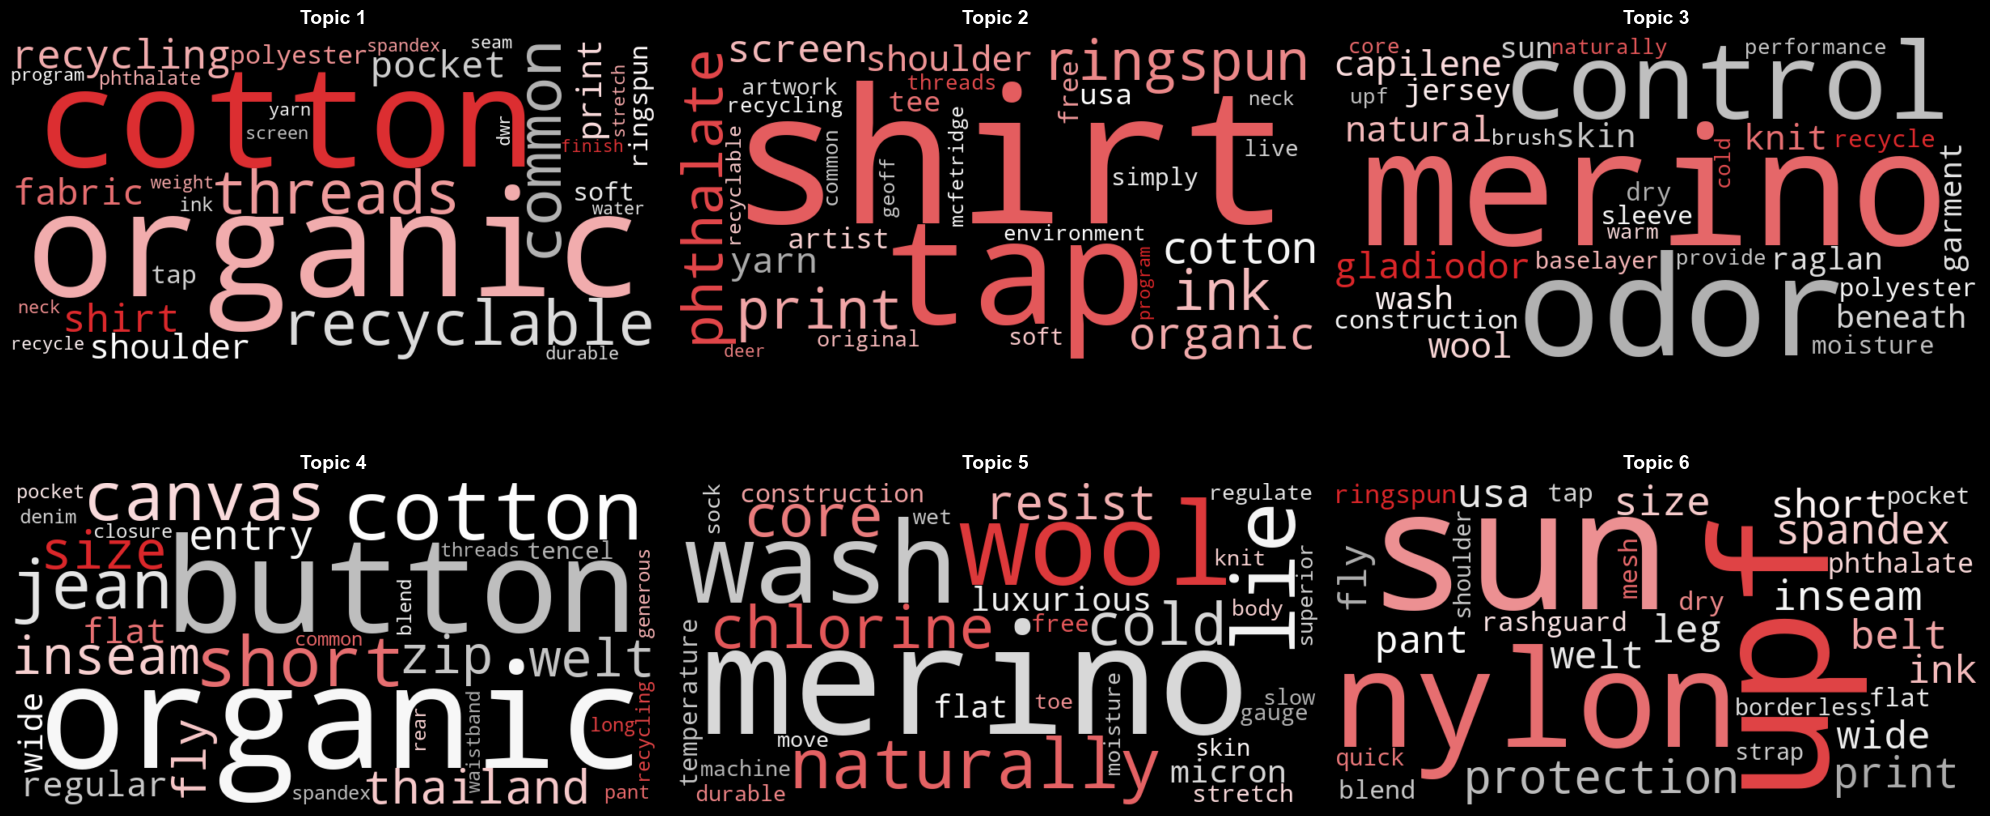

In [14]:
# WordClouds des topics LSA (basés sur les poids des composantes SVD)
def plot_topic_wordclouds(model, feature_names, n_topics_to_show=6):
    """Génère un WordCloud par topic à partir des poids SVD."""
    n_cols = 3
    n_rows = (n_topics_to_show + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), facecolor='black')
    axes = axes.flatten()
    
    for topic_idx in range(n_topics_to_show):
        topic_weights = model.components_[topic_idx]
        word_weights = {feature_names[i]: max(topic_weights[i], 0) 
                        for i in range(len(feature_names)) 
                        if topic_weights[i] > 0}
        
        if word_weights:
            wc = WordCloud(
                background_color='black',
                max_words=30,
                colormap=tnf_cmap,
                width=800, height=400
            ).generate_from_frequencies(word_weights)
            
            axes[topic_idx].imshow(wc, interpolation='bilinear')
            axes[topic_idx].set_title(
                f"Topic {topic_idx + 1}",
                color='white', fontsize=14, fontweight='bold', pad=10
            )
        axes[topic_idx].axis("off")
        axes[topic_idx].set_facecolor('black')
    
    plt.tight_layout()
    plt.show()

print("🎨 WordClouds des 6 premiers topics LSA :")
plot_topic_wordclouds(lsa_model, feature_names, n_topics_to_show=6)